## LangGraph
intro

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

load_dotenv()

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0,
    api_key=os.getenv("OPENAI_API_KEY")
)

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

print("✅ Ready")

✅ Ready


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# 1. Define State
class GraphState(TypedDict):
    message: str


# 2. Define Nodes (functions)
def say_hello(state: GraphState):
    print("🎬 Node 'say_hello' running...")
    return {"message": "Hello"}


def say_world(state: GraphState):
    print("🎬 Node 'say_world' running...")
    new_message = state["message"] + " World!"
    return {"message": new_message}


# 3. Build the Graph
builder = StateGraph(GraphState)

builder.add_node("hello_node", say_hello)
builder.add_node("world_node", say_world)

builder.add_edge(START, "hello_node")
builder.add_edge("hello_node", "world_node")
builder.add_edge("world_node", END)

# 4. Compile
graph = builder.compile()

# 5. Run
result = graph.invoke({"message": ""})
print("\nFinal state:", result)

🎬 Node 'say_hello' running...
🎬 Node 'say_world' running...

Final state: {'message': 'Hello World!'}


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
import random


# State
class NumberState(TypedDict):
    number: int
    result: str


# Nodes
def pick_number(state: NumberState):
    n = random.randint(1, 100)
    print(f"🎲 Picked number: {n}")
    return {"number": n}


def handle_even(state: NumberState):
    print("🟢 Even handler")
    return {"result": f"{state['number']} is EVEN"}


def handle_odd(state: NumberState):
    print("🔴 Odd handler")
    return {"result": f"{state['number']} is ODD"}


# Conditional function — returns the NAME of the next node
def is_even_or_odd(state: NumberState) -> str:
    if state["number"] % 2 == 0:
        return "even_node"
    return "odd_node"


# Build graph
builder = StateGraph(NumberState)

builder.add_node("picker", pick_number)
builder.add_node("even_node", handle_even)
builder.add_node("odd_node", handle_odd)

builder.add_edge(START, "picker")

# Conditional edge — picker tugagach, qaerga ketamiz?
builder.add_conditional_edges(
    "picker",
    is_even_or_odd,
    {
        "even_node": "even_node",
        "odd_node": "odd_node"
    }
)

builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

graph = builder.compile()

# Run 3 times to see different paths
for i in range(3):
    print(f"\n--- Run {i+1} ---")
    result = graph.invoke({"number": 0, "result": ""})
    print(f"Final: {result['result']}")


--- Run 1 ---
🎲 Picked number: 67
🔴 Odd handler
Final: 67 is ODD

--- Run 2 ---
🎲 Picked number: 86
🟢 Even handler
Final: 86 is EVEN

--- Run 3 ---
🎲 Picked number: 83
🔴 Odd handler
Final: 83 is ODD


In [4]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage


# 1. State — messages list saqlaymiz
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# 2. LLM Node
def call_llm(state: AgentState):
    print("🧠 LLM thinking...")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 3. Tool Node
def call_tools(state: AgentState):
    print("🔧 Running tools...")
    last_message = state["messages"][-1]
    tool_messages = []
    
    for tool_call in last_message.tool_calls:
        result = multiply.invoke(tool_call["args"])
        print(f"   → {tool_call['name']}({tool_call['args']}) = {result}")
        tool_messages.append(ToolMessage(
            content=str(result),
            tool_call_id=tool_call["id"]
        ))
    
    return {"messages": tool_messages}


# 4. Conditional — tool kerakmi yoki tugadik?
def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return "end"


# 5. Build graph
builder = StateGraph(AgentState)

builder.add_node("llm", call_llm)
builder.add_node("tools", call_tools)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",   # tool kerak → tools node
        "end": END          # tool kerak emas → tugatish
    }
)

builder.add_edge("tools", "llm")  # tools tugagach → llm ga qaytish (loop!)

graph = builder.compile()

print("✅ Agent graph compiled")

✅ Agent graph compiled


In [5]:
result = graph.invoke({
    "messages": [
        SystemMessage(content="You are a math assistant. Use tools when needed. Call only one tool at a time for sequential operations."),
        HumanMessage(content="Multiply 5847 by 9382, then multiply that result by 10.")
    ]
})

print("\n--- Full message history ---")
for msg in result["messages"]:
    msg_type = msg.__class__.__name__
    content_preview = msg.content[:80] if msg.content else "(empty — tool call)"
    print(f"[{msg_type}]: {content_preview}")

print("\n--- Final answer ---")
print(result["messages"][-1].content)

🧠 LLM thinking...
🔧 Running tools...
   → multiply({'a': 5847, 'b': 9382}) = 54856554
🧠 LLM thinking...
🔧 Running tools...
   → multiply({'a': 54856554, 'b': 10}) = 548565540
🧠 LLM thinking...

--- Full message history ---
[SystemMessage]: You are a math assistant. Use tools when needed. Call only one tool at a time fo
[HumanMessage]: Multiply 5847 by 9382, then multiply that result by 10.
[AIMessage]: (empty — tool call)
[ToolMessage]: 54856554
[AIMessage]: (empty — tool call)
[ToolMessage]: 548565540
[AIMessage]: The result of multiplying 5847 by 9382, and then multiplying that result by 10 i

--- Final answer ---
The result of multiplying 5847 by 9382, and then multiplying that result by 10 is 548565540.


In [6]:
# Get Mermaid text
mermaid_code = graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	llm -. &nbsp;end&nbsp; .-> __end__;
	llm -.-> tools;
	tools --> llm;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



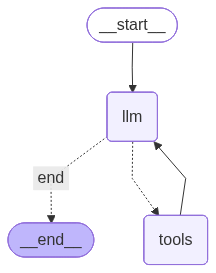

In [9]:
Image(graph.get_graph().draw_mermaid_png())